- First we saw in Missing imputation is CCA(removing complete row we saw in this)
- Then numerical(in this we learn three techniques)
- Then Categorical (in this we saw two techniques)

# Random Imputation

- we can apply on numerical & and categorical data
- We choose these numbers randomly from other numbers that is present in column.
- we need to do this with pandas because its not avaiale in sklearn.
- The best thing about it is data distribution does not change.

It is good for linear regression because keep data distribution same is important but it reduce covariance with other columns because we use random values. nut it s not good for decision tree algo.

### First randomness on Numerical data

In [1]:
import numpy as np 
import pandas as pd 

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt 
import seaborn as sns

In [21]:
df = pd.read_csv("../datasets/titanic/train.csv",usecols=["Age", "Fare", "Survived"])

In [22]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [23]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [24]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [26]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [27]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [28]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [29]:
# Fill missing Age values in train set using random samples from train's observed Age values
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

# Fill missing Age values in test set using random samples from TRAIN's observed Age values (prevents data leakage)
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

In [30]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([28.  , 36.  , 17.  , 21.  , 17.  , 14.  , 17.  , 36.  , 30.  ,
       27.  , 36.  , 46.  , 24.  , 45.  ,  2.  , 22.  , 24.  , 34.  ,
       16.  , 26.  , 28.  , 20.  , 30.  , 16.  , 61.  , 40.  , 19.  ,
       23.  , 45.5 , 34.  , 19.  , 42.  , 28.  , 31.  , 30.  , 16.  ,
       16.  , 30.  , 23.  , 54.  , 26.  , 14.  , 33.  , 26.  , 20.  ,
       32.  , 17.  , 56.  , 30.  , 20.  , 24.  , 27.  , 18.  , 31.  ,
       27.  , 35.  , 24.  , 49.  , 25.  , 51.  ,  4.  , 36.  , 36.  ,
       30.  , 19.  , 45.  , 21.  ,  2.  ,  9.  , 52.  , 30.  , 65.  ,
       38.  ,  9.  , 39.  , 41.  , 16.  , 15.  , 20.  , 30.  , 31.  ,
       28.  , 31.  ,  0.83, 18.  , 34.  , 45.  , 71.  , 22.  , 11.  ,
       22.  , 14.  , 27.  , 19.  , 27.  , 38.  , 38.  , 22.  , 26.  ,
       60.  ,  7.  , 41.  , 29.  , 19.  , 29.  , 28.  ,  2.  , 35.  ,
       43.  ,  4.  , 25.  , 25.  , 24.  , 15.  , 26.  , 25.  , 29.  ,
       22.  , 48.  , 28.  , 42.  , 32.  , 32.  , 30.  , 45.  , 52.  ,
       26.  , 44.  ,

/var/folders/qz/mzd2tgwd11d84yscm9mg7wq40000gn/T/ipykernel_3345/2642582470.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
/var/folders/qz/mzd2tgwd11d84yscm9mg7wq40000gn/T/ipykernel_3345/2642582470.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5

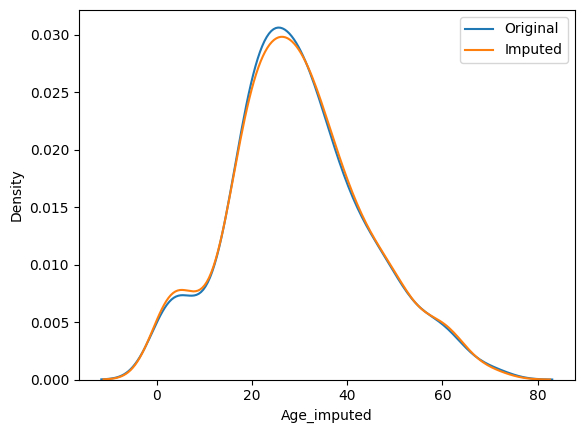

In [31]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label = 'Imputed',hist=False)

plt.legend()
plt.show()

In [32]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  207.3329839771093


In [33]:
X_train[['Fare', 'Age', 'Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,62.195317
Age,71.512440,204.349513,204.349513
Age_imputed,62.195317,204.349513,207.332984


<Axes: >

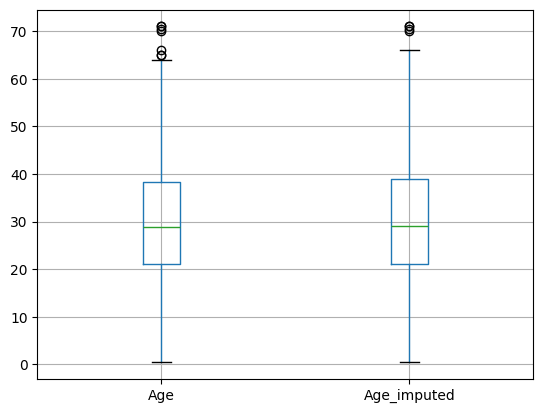

In [34]:
X_train[['Age', 'Age_imputed']].boxplot()

## House Dataset

In [38]:
data = pd.read_csv('../datasets/house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [39]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [40]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [41]:
X = data
y = data['SalePrice']

In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [43]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [44]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1085,NaN,TA,147000,TA,NaN
1224,Gd,TA,184000,TA,Gd
538,Fa,TA,158000,TA,Fa
456,NaN,Fa,98000,Fa,NaN
1062,NaN,TA,90000,TA,NaN


In [45]:
# same as above. filling in random values from their own column

X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/var/folders/qz/mzd2tgwd11d84yscm9mg7wq40000gn/T/ipykernel_3345/1354787899.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
/var/folders/qz/mzd2tgwd11d84yscm9mg7wq40000gn/T/ipykernel_3345/1354787899.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values
/var/folders/qz/mzd2tgwd11d84yscm9mg7wq40000gn/T/ipykernel_3345/1

In [46]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

Comparing the category distribution of GarageQual before and after imputation:

If the distributions are similar, the imputation didn't distort the data. If they differ, the imputation introduced bias.

In [47]:
temp

,original,imputed
TA,0.951043,0.949486
Fa,0.037171,0.039384
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [48]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.647587
TA,0.412439,0.539843
Fa,0.040917,0.052750
Po,0.027823,0.038159
Ex,0.024550,0.032548


/var/folders/qz/mzd2tgwd11d84yscm9mg7wq40000gn/T/ipykernel_3345/674568557.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
/var/folders/qz/mzd2tgwd11d84yscm9mg7wq40000gn/T/ipykernel_3345/674568557.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com

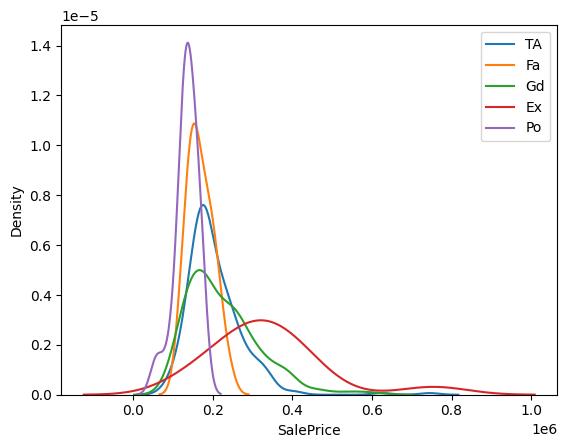

In [51]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.legend()
plt.show()

/var/folders/qz/mzd2tgwd11d84yscm9mg7wq40000gn/T/ipykernel_3345/2444536599.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
/var/folders/qz/mzd2tgwd11d84yscm9mg7wq40000gn/T/ipykernel_3345/2444536599.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.

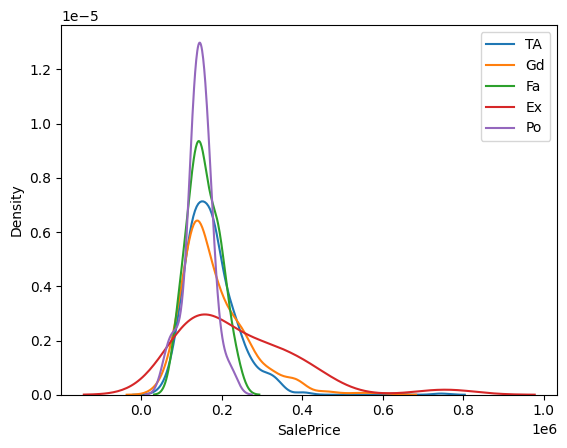

In [53]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.legend()
plt.show()